In [ ]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tqdm.auto import tqdm

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS
from model import ADModel
from dataset import create_dataloaders

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <3F789787-FE38-3CE7-8599-064BDD0416EE> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib
  warn(f"Failed to load image Python extension: {e}")
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: 创建整个Pitt数据集的CSV文件


In [ ]:
PROJECT_ROOT = script_dir.parent.parent

# 合并Pitt训练集和验证集，创建包含整个Pitt corpus的CSV文件
PITT_TRAIN_CSV = PROJECT_ROOT / "data/processed/pitt-train.csv"
PITT_VAL_CSV = PROJECT_ROOT / "data/processed/pitt-val.csv"
PITT_TEST_CSV = PROJECT_ROOT / "data/processed/pitt-test.csv"

# 读取训练集和验证集
pitt_train_df = pd.read_csv(PITT_TRAIN_CSV)
pitt_val_df = pd.read_csv(PITT_VAL_CSV)

# 合并两个数据集
pitt_test_df = pd.concat([pitt_train_df, pitt_val_df], ignore_index=True)

# 保存为测试集CSV
pitt_test_df.to_csv(PITT_TEST_CSV, index=False)

print(f"✅ Pitt数据集CSV已创建: {PITT_TEST_CSV}")
print(f"   总样本数: {len(pitt_test_df)}")
print(f"   Control: {(pitt_test_df['ad'] == 0).sum()}")
print(f"   Dementia: {(pitt_test_df['ad'] == 1).sum()}")

✅ Pitt数据集CSV已创建: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/pitt-test.csv
   总样本数: 551
   Control: 242
   Dementia: 309


## Step 2: 加载在Lu数据集上训练的最佳模型 (seed = 42)

In [3]:
# 直接使用指定seed的模型（seed 42）
LU_MODELS_DIR = PROJECT_ROOT / "models" / "lu_multi_seed"
SPECIFIED_SEED = "42"  # 可以修改这里来指定不同的seed

BEST_MODEL_PATH = LU_MODELS_DIR / f"seed_{SPECIFIED_SEED}" / "best.ckpt"

# 加载checkpoint
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cpu')

# 尝试从checkpoint中读取验证准确率
val_acc = 0
if 'callbacks' in checkpoint:
    for cb in checkpoint['callbacks'].values():
        if isinstance(cb, dict) and 'best_model_score' in cb:
            val_acc = cb['best_model_score']
            if isinstance(val_acc, torch.Tensor):
                val_acc = val_acc.item()
            break

print(f"   加载Lu训练的模型 (Seed {SPECIFIED_SEED})")
print(f"   模型路径: {BEST_MODEL_PATH}")
print(f"   Seed: {SPECIFIED_SEED}")
if val_acc > 0:
    print(f"   Lu验证准确率: {val_acc*100:.2f}%")


   加载Lu训练的模型 (Seed 42)
   模型路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/lu_multi_seed/seed_42/best.ckpt
   Seed: 42
   Lu验证准确率: 90.91%


In [4]:
# 创建模型实例
model = ADModel(DEFAULT_CONFIG)

# 处理 state_dict 键名 (移除 'model.' 前缀)
state_dict = checkpoint['state_dict']
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('model.'):
        new_key = key[6:]  # 移除 'model.' 前缀
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value

model.load_state_dict(new_state_dict)
model.eval()

print(f"   模型配置: {DEFAULT_CONFIG}")
print(f"   参数量: {sum(p.numel() for p in model.parameters()):,}")


   模型配置: ModelConfig(dim_input=25, dim_hidden=12, dropout=0.2)
   参数量: 725


## Step 3: 在Pitt数据集上进行测试


In [5]:
from torch.utils.data import Dataset, DataLoader

class PittDataset(Dataset):
    """Pitt数据集"""
    def __init__(self, csv_path, project_root):
        self.project_root = project_root
        self.df = pd.read_csv(csv_path)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feature_path = self.project_root / row['egemaps_path']
        features = torch.load(feature_path)
        label = int(row['ad'])
        return features, label

# 使用整个Pitt数据集进行测试
PITT_TEST_CSV = PROJECT_ROOT / "data/processed/pitt-test.csv"

# 创建数据加载器
pitt_dataset = PittDataset(PITT_TEST_CSV, PROJECT_ROOT)
pitt_loader = DataLoader(pitt_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"   总样本数: {len(pitt_dataset)}")
print(f"   Control: {(pitt_dataset.df['ad'] == 0).sum()}")
print(f"   Dementia: {(pitt_dataset.df['ad'] == 1).sum()}")

# 进行预测
all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for features, labels in tqdm(pitt_loader, desc="测试中"):
        logits = model(features)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# 计算准确率
accuracy = accuracy_score(all_labels, all_preds)

print(f"\n" + "="*60)
print(f"在 Pitt 数据集上的测试结果 (Lu训练模型)")
print(f"="*60)
print(f"总准确率: {accuracy*100:.2f}%")
print(f"\n详细分类报告:")
print(classification_report(all_labels, all_preds, target_names=['Control', 'Dementia']))


   总样本数: 551
   Control: 242
   Dementia: 309


测试中: 100%|██████████| 18/18 [00:00<00:00, 135.18it/s]


在 Pitt 数据集上的测试结果 (Lu训练模型)
总准确率: 47.19%

详细分类报告:
              precision    recall  f1-score   support

     Control       0.44      0.78      0.56       242
    Dementia       0.57      0.23      0.33       309

    accuracy                           0.47       551
   macro avg       0.51      0.50      0.45       551
weighted avg       0.51      0.47      0.43       551



## Step 4: Lu vs Pitt 性能对比

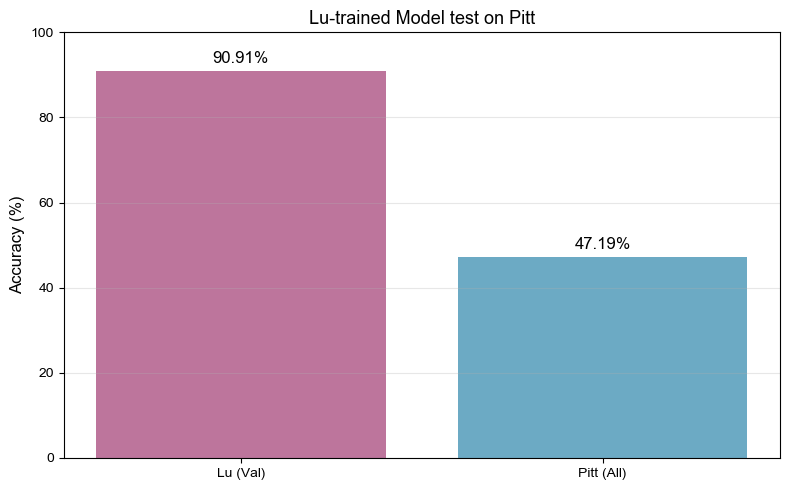


Lu Validation Accuracy: 90.91%
Pitt Accuracy: 47.19%
Performance Drop: 43.72%


In [6]:
# 使用之前从checkpoint读取的验证准确率
lu_val_acc = val_acc * 100 if val_acc > 0 else None

if lu_val_acc is None:
    print("⚠️ 无法从checkpoint读取Lu验证准确率")
    print("请手动设置 lu_val_acc 变量，或从 train_on_lu.ipynb 的结果中获取")
    lu_val_acc = 90.91  # 默认值，根据实际训练结果更新
    print(f"使用默认值: {lu_val_acc:.2f}%")

pitt_test_acc = accuracy * 100

# Simple comparison plot
fig, ax = plt.subplots(figsize=(8, 5))

datasets = ['Lu (Val)', 'Pitt (All)']
accuracies = [lu_val_acc, pitt_test_acc]

ax.bar(datasets, accuracies, color=['#A23B72', '#2E86AB'], alpha=0.7)
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Lu-trained Model test on Pitt', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(accuracies):
    ax.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nLu Validation Accuracy: {lu_val_acc:.2f}%")
print(f"Pitt Accuracy: {pitt_test_acc:.2f}%")
print(f"Performance Drop: {abs(lu_val_acc - pitt_test_acc):.2f}%")
